DATASET OVERVIEW
Samples: 1866
Features: 13
Time steps (records): 13632
Size: 2522.93 MB

FEATURE STATISTICS (across all samples & locations)
 0. Latitude     | min:      18.65 | max:      53.47 | mean:      33.38
 1. Longitude    | min:      75.25 | max:     133.99 | mean:     112.43
 2. Altitude     | min:     -47.20 | max:    4613.00 | mean:     605.86
 3. Air pressure | min:     564.90 | max:    1050.00 | mean:     948.94
 4. Air Temperature | min:     -17.50 | max:      47.20 | mean:      14.42
 5. Maximum Temperature | min:     -16.85 | max:      48.10 | mean:      14.91
 6. Minimum Temperature | min:     -17.75 | max:      46.90 | mean:      13.94
 7. Relative humidity | min:       0.00 | max:     100.00 | mean:      67.57
 8. Precipitation in 3h | min:      -1.00 | max:    1049.70 | mean:       0.34
 9. Wind direction | min:       0.00 | max:     360.00 | mean:     174.47
10. Wind speed   | min:       0.00 | max:      37.70 | mean:       2.08
11. Maximum wind direction | min:  

c:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Unique Latitude values: 1234
Unique Longitude values: 1306
Altitude range: -47m to 4613m


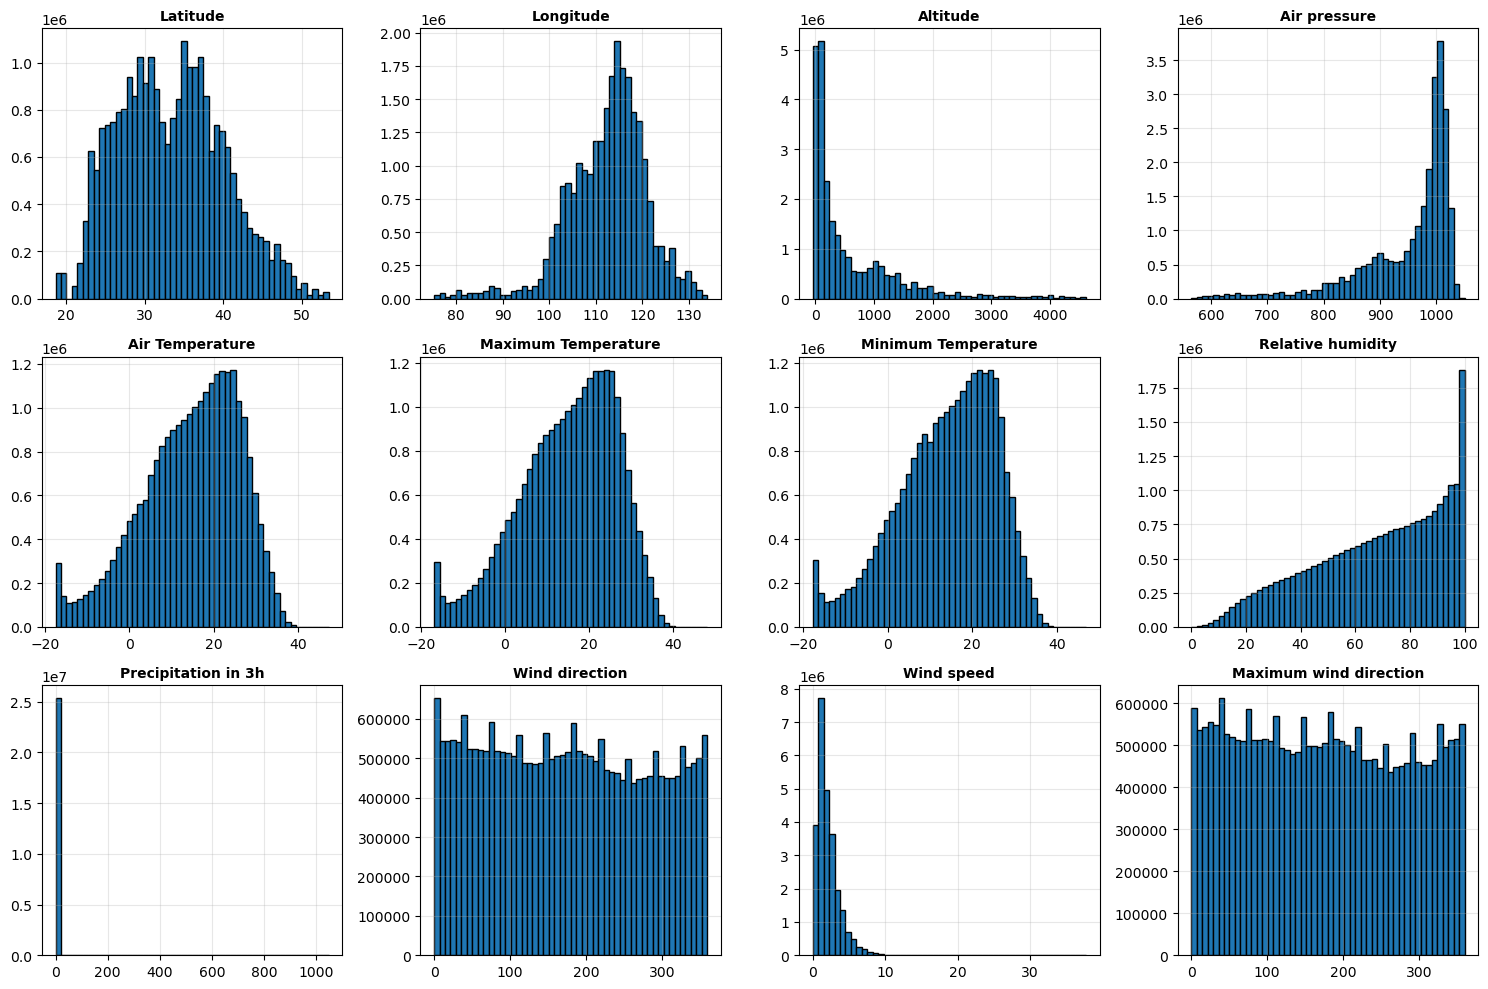

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import time
import os

# Load data
data = np.load(r"weather2k.npy", allow_pickle=True)

# Feature names
features = ['Latitude', 'Longitude', 'Altitude', 'Air pressure', 'Air Temperature', 'Maximum Temperature', 'Minimum Temperature', 'Relative humidity', 'Precipitation in 3h', 
            'Wind direction', 'Wind speed', 'Maximum wind direction', 'Maximum wind speed']

print("="*60)
print("DATASET OVERVIEW")
print("="*60)
print(f"Samples: {data.shape[0]}")
print(f"Features: {data.shape[1]}")
print(f"Time steps (records): {data.shape[2]}")
print(f"Size: {data.nbytes / (1024**2):.2f} MB\n")

print("="*60)
print("FEATURE STATISTICS (across all samples & locations)")
print("="*60)
for i, fname in enumerate(features[:data.shape[1]]):
    feature_data = data[:, i, :]
    print(f"{i:2d}. {fname:12s} | min: {feature_data.min():10.2f} | "
          f"max: {feature_data.max():10.2f} | mean: {feature_data.mean():10.2f}")

print("\n" + "="*60)
print("DATA QUALITY CHECK")
print("="*60)
print(f"NaN values: {np.isnan(data).sum()}")
print(f"Inf values: {np.isinf(data).sum()}")
print(f"Zero values: {(data == 0).sum()} ({(data == 0).sum() / data.size * 100:.2f}%)")

print("\n" + "="*60)
print("SAMPLE ANALYSIS")
print("="*60)
print(f"Sample 0 temp range: {data[0, 4, :].min():.1f}°C to {data[0, 4, :].max():.1f}°C")
print(f"Sample 0 humidity range: {data[0, 7, :].min():.1f}% to {data[0, 7, :].max():.1f}%")

# Visualize feature distributions
fig, axes = plt.subplots(3, 4, figsize=(15, 10))
axes = axes.flatten()

for i in range(min(12, data.shape[1])):
    feature_data = data[:, i, :].flatten()
    axes[i].hist(feature_data[~np.isnan(feature_data)], bins=50, edgecolor='black')
    axes[i].set_title(f"{features[i]}", fontsize=10, fontweight='bold')
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('weather_features_distribution.png', dpi=100)
print("\n✓ Saved feature distributions to 'weather_features_distribution.png'")

# Correlation analysis
print("\n" + "="*60)
print("FEATURE CORRELATIONS (sample 0)")
print("="*60)
sample_data = data[0, :, :].T  # Transpose to (locations, features)
corr_matrix = np.corrcoef(sample_data.T)

# Show strongest correlations
for i in range(min(5, data.shape[1])):
    for j in range(i+1, min(5, data.shape[1])):
        print(f"{features[i]:6s} vs {features[j]:6s}: {corr_matrix[i, j]:6.3f}")

print("\n" + "="*60)
print("SPATIAL ANALYSIS")
print("="*60)
print(f"Unique Latitude values: {len(np.unique(data[:, 0, :]))}")
print(f"Unique Longitude values: {len(np.unique(data[:, 1, :]))}")
print(f"Altitude range: {data[:, 2, :].min():.0f}m to {data[:, 2, :].max():.0f}m")

In [ ]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import os

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

Using device: cuda
GPU: NVIDIA GeForce RTX 3050 Ti Laptop GPU


In [4]:
# Check the original table more carefully
print(f"Total features in data: {data.shape[1]}")
print("\nChecking all features:")

for i in range(data.shape[1]):
    print(f"Index {i}: range [{data[:, i, :].min():.2f}, {data[:, i, :].max():.2f}]")

# Specifically check if 5 and 6 are both temperature-related
print("\n--- Temperature Analysis ---")
print(f"Index 5: {data[:, 5, :].min():.2f} to {data[:, 5, :].max():.2f}")
print(f"Index 6: {data[:, 6, :].min():.2f} to {data[:, 6, :].max():.2f}")

# Check if one is consistently higher (max) than the other (min)
sample_station = 0
sample_time = 100
print(f"\nSample comparison at station {sample_station}, time {sample_time}:")
print(f"Index 5: {data[sample_station, 5, sample_time]:.2f}")
print(f"Index 6: {data[sample_station, 6, sample_time]:.2f}")

Total features in data: 13

Checking all features:
Index 0: range [18.65, 53.47]
Index 1: range [75.25, 133.99]
Index 2: range [-47.20, 4613.00]
Index 3: range [564.90, 1050.00]
Index 4: range [-17.50, 47.20]
Index 5: range [-16.85, 48.10]
Index 6: range [-17.75, 46.90]
Index 7: range [0.00, 100.00]
Index 8: range [-1.00, 1049.70]
Index 9: range [0.00, 360.00]
Index 10: range [0.00, 37.70]
Index 11: range [0.00, 360.00]
Index 12: range [0.00, 48.90]

--- Temperature Analysis ---
Index 5: -16.85 to 48.10
Index 6: -17.75 to 46.90

Sample comparison at station 0, time 100:
Index 5: -14.90
Index 6: -15.30


In [5]:
# apply log transform to the precipitation
# Index 8 is precipitation column
PRECIP_IDX = 8

# Add small constant to avoid log(0), then log transform, the log transform would work because the column data is right-skewed data
data[:, PRECIP_IDX, :] = np.log1p(data[:, PRECIP_IDX, :])  # log1p = log(1 + x)
print(f"Applied log transform to precipitation")

# Wind direction is circular - convert to sin/cos
# Indices 9 and 11 are wind directions
WD_INDICES = [9, 11]

for wd_idx in WD_INDICES:
    # Convert degrees to radians, then to sin/cos
    rad = np.deg2rad(data[:, wd_idx, :])
    sin_component = np.sin(rad)
    cos_component = np.cos(rad)
    
    # Replace original with sin, append cos as new feature
    data[:, wd_idx, :] = sin_component
    # Add cos component as new feature
    cos_feature = cos_component[np.newaxis, :, :]  # Add feature dimension
    data = np.concatenate([data, cos_feature.transpose(1, 0, 2)], axis=1)

print(f"Converted wind directions to sin/cos. New shape: {data.shape}")

C:\Users\mamou\AppData\Local\Temp\ipykernel_24556\2054478675.py:6: RuntimeWarning: divide by zero encountered in log1p
  data[:, PRECIP_IDX, :] = np.log1p(data[:, PRECIP_IDX, :])  # log1p = log(1 + x)


Applied log transform to precipitation
Converted wind directions to sin/cos. New shape: (1866, 15, 13632)


In [6]:
# Original feature names
features = [
    "Latitude", "Longitude", "Altitude", "Air pressure", "Air Temperature",
    "Maximum Temperature", "Minimum Temperature", "Relative humidity",
    "Precipitation", "Wind direction", "Wind speed", "Max wind dir", "Max wind speed"
]

# Add cos features for wind directions
for idx in WD_INDICES:
    features.append(f"{features[idx]}_cos")

print("New feature names:")
# Compute min, max, mean for all features
print("\nFEATURE STATS (with new cos features)")
for i, f in enumerate(features):
    feature_data = data[:, i, :].flatten()
    print(f"{i:2d}. {f:25s} | min: {feature_data.min():10.2f} | max: {feature_data.max():10.2f} | mean: {feature_data.mean():10.2f}")

New feature names:

FEATURE STATS (with new cos features)
 0. Latitude                  | min:      18.65 | max:      53.47 | mean:      33.38
 1. Longitude                 | min:      75.25 | max:     133.99 | mean:     112.43
 2. Altitude                  | min:     -47.20 | max:    4613.00 | mean:     605.86
 3. Air pressure              | min:     564.90 | max:    1050.00 | mean:     948.94
 4. Air Temperature           | min:     -17.50 | max:      47.20 | mean:      14.42
 5. Maximum Temperature       | min:     -16.85 | max:      48.10 | mean:      14.91
 6. Minimum Temperature       | min:     -17.75 | max:      46.90 | mean:      13.94
 7. Relative humidity         | min:       0.00 | max:     100.00 | mean:      67.57
 8. Precipitation             | min:       -inf | max:       6.96 | mean:       -inf
 9. Wind direction            | min:      -1.00 | max:       1.00 | mean:       0.03
10. Wind speed                | min:       0.00 | max:      37.70 | mean:       2.08
11. Max

In [7]:
print(f"Shape: {data.shape}")

# Check for NaN/Inf values
nan_count = np.isnan(data).sum()
inf_count = np.isinf(data).sum()
print(f"NaN values: {nan_count}, Inf values: {inf_count}")

if nan_count > 0 or inf_count > 0:
    for i in range(data.shape[1]):
        feature = data[:, i, :]
        # Calculate median only on finite values
        valid_mask = np.isfinite(feature)
        if valid_mask.any():
            median_val = np.median(feature[valid_mask])
        else:
            median_val = 0.0
        
        # Replace NaN and Inf with median
        data[:, i, :] = np.where(np.isfinite(feature), feature, median_val)
    
    print("Replaced NaN/Inf with median values")
    print(f"After fix - NaN: {np.isnan(data).sum()}, Inf: {np.isinf(data).sum()}")

Shape: (1866, 15, 13632)
NaN values: 0, Inf values: 3645
Replaced NaN/Inf with median values
After fix - NaN: 0, Inf: 0


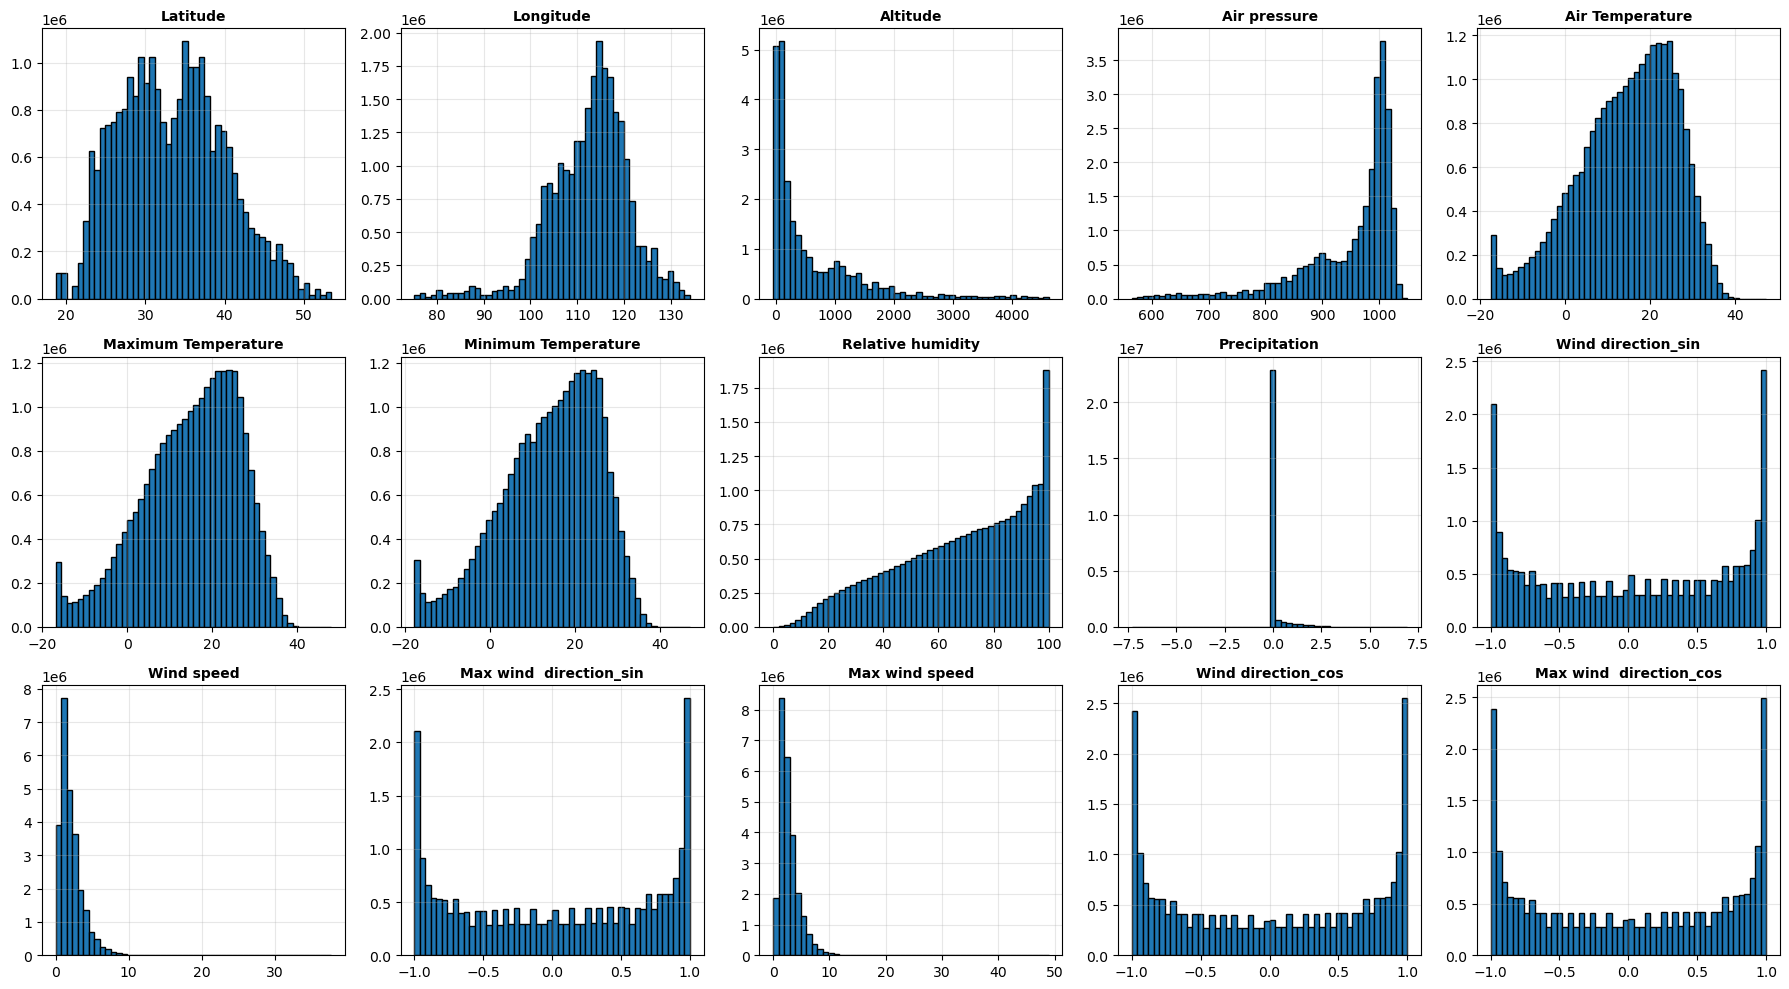

In [8]:
# Feature names
features = ['Latitude', 'Longitude', 'Altitude', 'Air pressure', 'Air Temperature', 
            'Maximum Temperature', 'Minimum Temperature', 'Relative humidity', 
            'Precipitation', 'Wind direction_sin', 'Wind speed', 
            'Max wind  direction_sin', 'Max wind speed', 'Wind direction_cos', 
            'Max wind  direction_cos']

# Visualize feature distributions
fig, axes = plt.subplots(3, 5, figsize=(18, 10))
axes = axes.flatten()

for i in range(data.shape[1]):  # All 15 features
    feature_data = data[:, i, :].flatten()
    axes[i].hist(feature_data[~np.isnan(feature_data)], bins=50, edgecolor='black')
    axes[i].set_title(f"{features[i]}", fontsize=10, fontweight='bold')
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('weather_features_distribution_after_preprocessing.png', dpi=100)
plt.show()

In [9]:
# Temporal split
n_timesteps = data.shape[2]  # 13632
n_train = int(0.7 * n_timesteps)
n_val = int(0.15 * n_timesteps)

train_data = data[:, :, :n_train]
val_data = data[:, :, n_train:n_train+n_val]
test_data = data[:, :, n_train+n_val:]

print(f"Train timesteps: {train_data.shape[2]}")
print(f"Val timesteps: {val_data.shape[2]}")
print(f"Test timesteps: {test_data.shape[2]}")

# Fit scaler on train data: (stations*timesteps, features)
train_flat = train_data.reshape(-1, train_data.shape[1])  # Flatten stations and timesteps
scaler = StandardScaler()
scaler.fit(train_flat)

def normalize_data(data, scaler):
    """Normalize data using fitted scaler"""
    n_stations, n_features, n_timesteps = data.shape
    data_flat = data.reshape(-1, n_features)  # (stations*timesteps, features)
    data_normalized = scaler.transform(data_flat)
    return data_normalized.reshape(n_stations, n_features, n_timesteps)

train_norm = normalize_data(train_data, scaler)
val_norm = normalize_data(val_data, scaler)
test_norm = normalize_data(test_data, scaler)

Train timesteps: 9542
Val timesteps: 2044
Test timesteps: 2046


In [10]:
class WeatherDataset(Dataset):
    def __init__(self, data, seq_len, pred_horizon, slide_step, target_idxs):
        """
        Args:
            data: (n_stations, n_features, n_timesteps)
            seq_len: input sequence length
            pred_horizon: number of future timesteps to predict
            slide_step: sliding window step size
            target_idxs: index of target feature (mxt/mnt)
        """
        self.data = data
        self.seq_len = seq_len
        self.pred_horizon = pred_horizon
        self.slide_step = slide_step
        self.target_idxs = target_idxs
        
        # Generate all valid window indices
        self.samples = []
        n_stations, n_features, n_timesteps = data.shape
        
        for station_idx in range(n_stations):
            for start_idx in range(0, n_timesteps - seq_len - pred_horizon + 1, slide_step):
                end_idx = start_idx + seq_len
                self.samples.append((station_idx, start_idx, end_idx))
        
        print(f"Created {len(self.samples)} windows")
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        station_idx, start_idx, end_idx = self.samples[idx]
        
        # Input: all features for seq_len timesteps
        X = self.data[station_idx, :, start_idx:end_idx]  # (n_features, seq_len)
        
        # Target: only mxt/mnt for next pred_horizon timesteps
        y = self.data[station_idx, self.target_idxs, end_idx:end_idx + self.pred_horizon]
        
        return torch.FloatTensor(X), torch.FloatTensor(y) # both (n_features, seq_len)

In [11]:
SEQ_LEN = 84      # 10.5 days
PRED_HORIZON = 8   # Predict next 8 timesteps (24 hours)
SLIDE_STEP = 8    # Slide by 56 steps (168 hours / 1 week)
TARGET_IDXS = [4, 5, 6, 8]

In [12]:
train_dataset = WeatherDataset(train_norm, SEQ_LEN, PRED_HORIZON, SLIDE_STEP, TARGET_IDXS)
val_dataset = WeatherDataset(val_norm, SEQ_LEN, PRED_HORIZON, SLIDE_STEP, TARGET_IDXS)
test_dataset = WeatherDataset(test_norm, SEQ_LEN, PRED_HORIZON, SLIDE_STEP, TARGET_IDXS)

Created 2205612 windows
Created 457170 windows
Created 457170 windows


In [14]:
# =========================================================
# Model configuration parameters
# =========================================================

num_features = train_norm.shape[1]
num_targets  = len(TARGET_IDXS)
horizon      = PRED_HORIZON

In [15]:
# =========================================================
# Bi-Directional LSTM model definition
# =========================================================

class BiLSTMModel(nn.Module):
    def __init__(self, num_features, hidden_size=64):
        super().__init__()
        
        self.lstm = nn.LSTM(
            input_size=num_features,
            hidden_size=hidden_size,
            batch_first=True,
            bidirectional=True
        )
        
        self.fc = nn.Linear(hidden_size * 2, num_targets * horizon)

    def forward(self, x):
        # x: (batch, features, seq_len)
        x = x.permute(0, 2, 1)   # (batch, seq_len, features)
        out, _ = self.lstm(x)
        out = out[:, -1, :]      # last timestep
        out = self.fc(out)
        return out.view(out.size(0), num_targets, horizon)

In [26]:
# =========================================================
# Model initialisation and training setup
# =========================================================

model = BiLSTMModel(num_features).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

In [27]:
# =========================================================
# Data loaders
# =========================================================

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False)

In [28]:
num_epochs = 20

train_losses = []
val_losses   = []

for epoch in range(num_epochs):

    # -------- Training --------
    model.train()
    train_loss = 0.0

    for X, y in train_loader:
        X = X.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        preds = model(X)
        loss = criterion(preds, y)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # -------- Validation --------
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X, y in val_loader:
            X = X.to(device)
            y = y.to(device)
            preds = model(X)
            loss = criterion(preds, y)
            val_loss += loss.item()

    val_loss /= len(val_loader)

    # Save losses
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Loss: {train_loss:.8f} | "
        f"Val Loss: {val_loss:.8f}"
    )

Epoch [1/20] | Train Loss: 0.00031664 | Val Loss: 0.00012908
Epoch [2/20] | Train Loss: 0.00004449 | Val Loss: 0.00009516
Epoch [3/20] | Train Loss: 0.00003988 | Val Loss: 0.00008603
Epoch [4/20] | Train Loss: 0.00003847 | Val Loss: 0.00008393
Epoch [5/20] | Train Loss: 0.00003774 | Val Loss: 0.00007764
Epoch [6/20] | Train Loss: 0.00003720 | Val Loss: 0.00008029
Epoch [7/20] | Train Loss: 0.00003679 | Val Loss: 0.00008464
Epoch [8/20] | Train Loss: 0.00003637 | Val Loss: 0.00008333
Epoch [9/20] | Train Loss: 0.00003600 | Val Loss: 0.00008112
Epoch [10/20] | Train Loss: 0.00003567 | Val Loss: 0.00008130
Epoch [11/20] | Train Loss: 0.00003539 | Val Loss: 0.00008393
Epoch [12/20] | Train Loss: 0.00003512 | Val Loss: 0.00008060
Epoch [13/20] | Train Loss: 0.00003487 | Val Loss: 0.00009092
Epoch [14/20] | Train Loss: 0.00003463 | Val Loss: 0.00007475
Epoch [15/20] | Train Loss: 0.00003442 | Val Loss: 0.00007949
Epoch [16/20] | Train Loss: 0.00003422 | Val Loss: 0.00007889
Epoch [17/20] | T

In [ ]:
torch.save(model.state_dict(), "bilstm_final.pt")

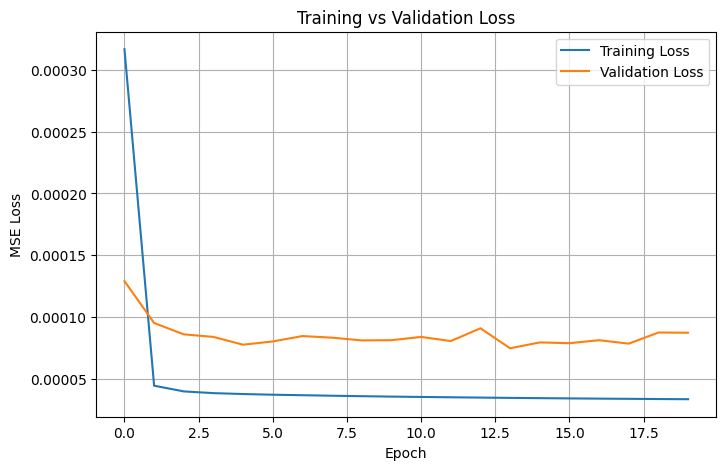

In [30]:
plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
BATCH_SIZE = 512 

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f"\nDataLoader Info:")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")


DataLoader Info:
Train batches: 4308
Val batches: 893
Test batches: 893


In [ ]:
criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.00006, weight_decay=0.01)

# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, verbose=True)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=4, gamma=0.7)

In [17]:
from torch.amp import autocast, GradScaler

# Mixed precision scaler
precision_scaler = GradScaler()

print(f"Using mixed precision training (AMP)")

Using mixed precision training (AMP)


In [34]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def calculate_metrics(y_true, y_pred):
    """Calculate RMSE, MAE, R2 for each target"""
    y_true = y_true.cpu().numpy()
    y_pred = y_pred.cpu().numpy()
    
    n_targets = y_true.shape[1]
    metrics = {}
    
    for i in range(n_targets):
        true_flat = y_true[:, i, :].flatten()
        pred_flat = y_pred[:, i, :].flatten()
        
        rmse = np.sqrt(mean_squared_error(true_flat, pred_flat))
        mae = mean_absolute_error(true_flat, pred_flat)
        r2 = r2_score(true_flat, pred_flat)
        
        metrics[f'target_{i}'] = {'rmse': rmse, 'mae': mae, 'r2': r2}
    
    # Overall averages
    metrics['avg'] = {
        'rmse': np.mean([metrics[f'target_{i}']['rmse'] for i in range(n_targets)]),
        'mae': np.mean([metrics[f'target_{i}']['mae'] for i in range(n_targets)]),
        'r2': np.mean([metrics[f'target_{i}']['r2'] for i in range(n_targets)])
    }
    
    return metrics

In [18]:
os.makedirs('statistics/BI-LSTM', exist_ok=True)
os.makedirs('BI-LSTM_models', exist_ok=True)

# Initialize metrics file with header
with open('statistics/BI-LSTM_training_metrics.txt', 'w') as f:
    f.write("Epoch,Time(s),Train_Loss,Val_Loss,LR,Train_RMSE,Train_MAE,Train_R2,Val_RMSE,Val_MAE,Val_R2\n")

print("Created directories and metrics file")

Created directories and metrics file


In [33]:
def train_epoch(model, loader, criterion, optimizer, device, scaler):
    model.train()
    total_loss = 0
    all_preds = []
    all_targets = []
    
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        
        optimizer.zero_grad()
        
        # Mixed precision forward pass
        with autocast('cuda'):
            output = model(X)
            loss = criterion(output, y)
        
        # Mixed precision backward pass
        precision_scaler.scale(loss).backward()
        precision_scaler.step(optimizer)
        precision_scaler.update()

        total_loss += loss.item()
        all_preds.append(output.detach())
        all_targets.append(y.detach())
    
    all_preds = torch.cat(all_preds, dim=0)
    all_targets = torch.cat(all_targets, dim=0)
    metrics = calculate_metrics(all_targets, all_preds)
    
    return total_loss / len(loader), metrics

def validate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            
            with autocast('cuda'):
                output = model(X)
                loss = criterion(output, y)
            
            total_loss += loss.item()
            all_preds.append(output)
            all_targets.append(y)
    
    all_preds = torch.cat(all_preds, dim=0)
    all_targets = torch.cat(all_targets, dim=0)
    metrics = calculate_metrics(all_targets, all_preds)
    
    return total_loss / len(loader), metrics

In [21]:
epoch = 41

In [32]:
def train(epochs):
    global epoch
    global best_val_loss
    print(f"\n{'='*80}")
    print(f"STARTING TRAINING - {epochs} EPOCHS")
    print(f"{'='*80}\n")

    for i in range(1, epochs + 1):
        epoch_start = time.time()
        
        # Train
        train_loss, train_metrics = train_epoch(model, train_loader, criterion, optimizer, device, scaler)
        
        # Validate
        val_loss, val_metrics = validate(model, val_loader, criterion, device)
        
        # Scheduler step
        scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']
        
        epoch_time = time.time() - epoch_start
        
        # Print metrics
        print(f"Epoch {epoch} | Time: {epoch_time:.2f}s")
        print(f"  Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f} | LR: {current_lr:.2e}")
        print(f"  Train - RMSE: {train_metrics['avg']['rmse']:.4f} | MAE: {train_metrics['avg']['mae']:.4f} | R2: {train_metrics['avg']['r2']:.4f}")
        print(f"  Val   - RMSE: {val_metrics['avg']['rmse']:.4f} | MAE: {val_metrics['avg']['mae']:.4f} | R2: {val_metrics['avg']['r2']:.4f}")
        print()
        
        # Save metrics to file
        with open('statistics/BI-LSTM_training_metrics.txt', 'a') as f:
            f.write(f"{epoch},{epoch_time:.2f},{train_loss:.6f},{val_loss:.6f},{current_lr:.2e},"
                    f"{train_metrics['avg']['rmse']:.4f},{train_metrics['avg']['mae']:.4f},{train_metrics['avg']['r2']:.4f},"
                    f"{val_metrics['avg']['rmse']:.4f},{val_metrics['avg']['mae']:.4f},{val_metrics['avg']['r2']:.4f}\n")
        
        # Save model after epoch 5
        if epoch >= 5:
            torch.save(model.state_dict(), f"BI-LSTM_models/model_epoch_{epoch}.pt")
        
            
        epoch += 1

    print(f"\n{'='*80}")
    print(f"TRAINING COMPLETE")
    print(f"{'='*80}")    

In [23]:
train(10)


STARTING TRAINING - 10 EPOCHS

Epoch 41 | Time: 122.00s
  Train Loss: 0.000042 | Val Loss: 0.000078 | LR: 6.00e-05
  Train - RMSE: 0.0059 | MAE: 0.0044 | R2: 0.7140
  Val   - RMSE: 0.0080 | MAE: 0.0062 | R2: 0.6475

Epoch 42 | Time: 117.33s
  Train Loss: 0.000038 | Val Loss: 0.000074 | LR: 6.00e-05
  Train - RMSE: 0.0056 | MAE: 0.0042 | R2: 0.7221
  Val   - RMSE: 0.0078 | MAE: 0.0060 | R2: 0.6552

Epoch 43 | Time: 115.99s
  Train Loss: 0.000037 | Val Loss: 0.000081 | LR: 6.00e-05
  Train - RMSE: 0.0056 | MAE: 0.0041 | R2: 0.7240
  Val   - RMSE: 0.0081 | MAE: 0.0063 | R2: 0.6465

Epoch 44 | Time: 120.34s
  Train Loss: 0.000037 | Val Loss: 0.000085 | LR: 4.20e-05
  Train - RMSE: 0.0055 | MAE: 0.0041 | R2: 0.7257
  Val   - RMSE: 0.0083 | MAE: 0.0064 | R2: 0.6347

Epoch 45 | Time: 113.14s
  Train Loss: 0.000037 | Val Loss: 0.000095 | LR: 4.20e-05
  Train - RMSE: 0.0055 | MAE: 0.0041 | R2: 0.7284
  Val   - RMSE: 0.0087 | MAE: 0.0068 | R2: 0.6270

Epoch 46 | Time: 118.30s
  Train Loss: 0.00

In [35]:
train(10)


STARTING TRAINING - 10 EPOCHS

Epoch 51 | Time: 119.56s
  Train Loss: 0.000036 | Val Loss: 0.000101 | LR: 8.00e-06
  Train - RMSE: 0.0055 | MAE: 0.0040 | R2: 0.7336
  Val   - RMSE: 0.0090 | MAE: 0.0070 | R2: 0.6058

Epoch 52 | Time: 117.24s
  Train Loss: 0.000036 | Val Loss: 0.000100 | LR: 8.00e-06
  Train - RMSE: 0.0054 | MAE: 0.0040 | R2: 0.7336
  Val   - RMSE: 0.0090 | MAE: 0.0070 | R2: 0.6070

Epoch 53 | Time: 116.69s
  Train Loss: 0.000036 | Val Loss: 0.000099 | LR: 8.00e-06
  Train - RMSE: 0.0054 | MAE: 0.0040 | R2: 0.7337
  Val   - RMSE: 0.0090 | MAE: 0.0070 | R2: 0.6066

Epoch 54 | Time: 115.80s
  Train Loss: 0.000036 | Val Loss: 0.000101 | LR: 5.60e-06
  Train - RMSE: 0.0054 | MAE: 0.0040 | R2: 0.7338
  Val   - RMSE: 0.0090 | MAE: 0.0070 | R2: 0.6060

Epoch 55 | Time: 116.42s
  Train Loss: 0.000036 | Val Loss: 0.000103 | LR: 5.60e-06
  Train - RMSE: 0.0054 | MAE: 0.0040 | R2: 0.7340
  Val   - RMSE: 0.0091 | MAE: 0.0071 | R2: 0.6002

Epoch 56 | Time: 115.61s
  Train Loss: 0.00

In [19]:
# =========================================================
# Model evaluation on the test set
# =========================================================

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for X, y in DataLoader(test_dataset, batch_size=64):
        X = X.to(device)
        preds = model(X).cpu().numpy()
        all_preds.append(preds)
        all_targets.append(y.numpy())

all_preds = np.concatenate(all_preds, axis=0)
all_targets = np.concatenate(all_targets, axis=0)

# flatten for metrics
preds_flat = all_preds.reshape(-1)
targets_flat = all_targets.reshape(-1)

mse = mean_squared_error(targets_flat, preds_flat)
rmse = np.sqrt(mse)

mae  = mean_absolute_error(targets_flat, preds_flat)
r2   = r2_score(targets_flat, preds_flat)

print(f"RMSE: {rmse:.8f}")
print(f"MAE : {mae:.8f}")
print(f"R²  : {r2:.8f}")

RMSE: 0.00831664
MAE : 0.00569845
R²  : 0.94426012


In [27]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

num_targets = all_targets.shape[1]
horizon = all_targets.shape[2]

print("Metrics per Target (averaged over horizon):\n")

for t in range(num_targets):
    
    y_true = all_targets[:, t, :].reshape(-1)
    y_pred = all_preds[:, t, :].reshape(-1)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)

    print(f"Target {t}:")
    print(f"  RMSE = {rmse:.8f}")
    print(f"  MAE  = {mae:.8f}")
    print(f"  R²   = {r2:.8f}\n")


Metrics per Target (averaged over horizon):

Target 0:
  RMSE = 0.00962945
  MAE  = 0.00738728
  R²   = 0.91848409

Target 1:
  RMSE = 0.00948767
  MAE  = 0.00726117
  R²   = 0.92054534

Target 2:
  RMSE = 0.00960019
  MAE  = 0.00732635
  R²   = 0.91903663

Target 3:
  RMSE = 0.00132679
  MAE  = 0.00081901
  R²   = -0.13136899



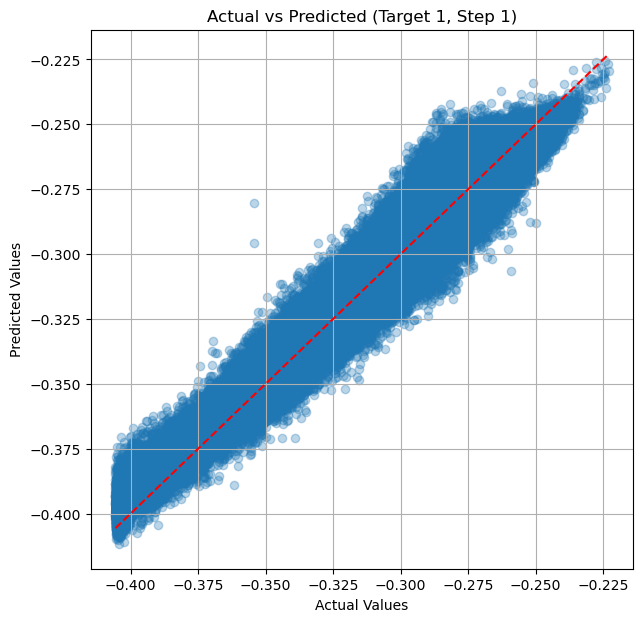

In [28]:
true_vals = all_targets[:, 0, 0]
pred_vals = all_preds[:, 0, 0]

plt.figure(figsize=(7,7))
plt.scatter(true_vals, pred_vals, alpha=0.3)
plt.plot(
    [true_vals.min(), true_vals.max()],
    [true_vals.min(), true_vals.max()],
    'r--'
)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted (Target 1, Step 1)")
plt.grid(True)
plt.show()

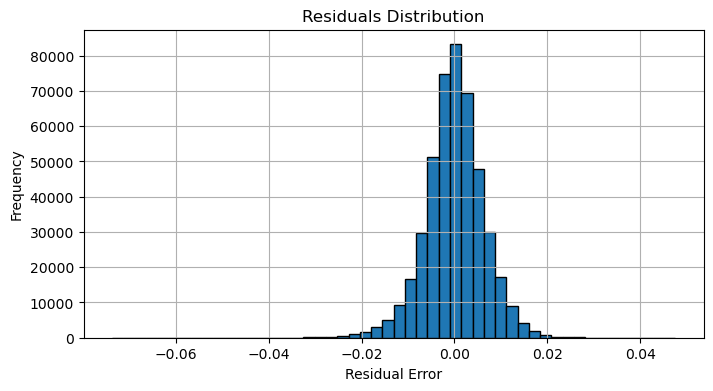

In [29]:
residuals = true_vals - pred_vals

plt.figure(figsize=(8,4))
plt.hist(residuals, bins=50, edgecolor="black")
plt.xlabel("Residual Error")
plt.ylabel("Frequency")
plt.title("Residuals Distribution")
plt.grid(True)
plt.show()